In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv("Energy1.csv")
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [4]:
df.shape

(768, 10)

In [5]:
df.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [7]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [8]:
df.isnull().sum()

X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

In [9]:
df = df.dropna()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

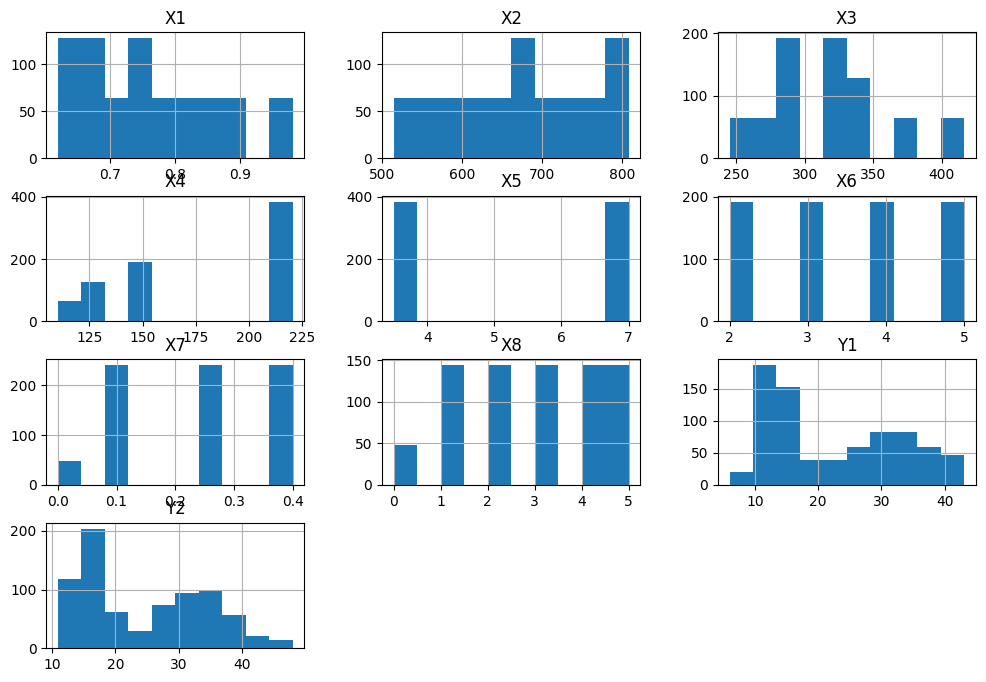

In [12]:
df.hist(figsize=(12,8))
plt.show()

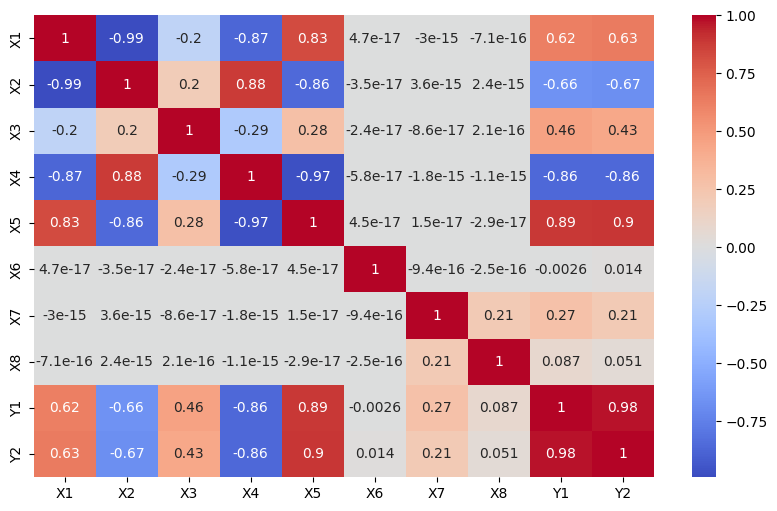

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

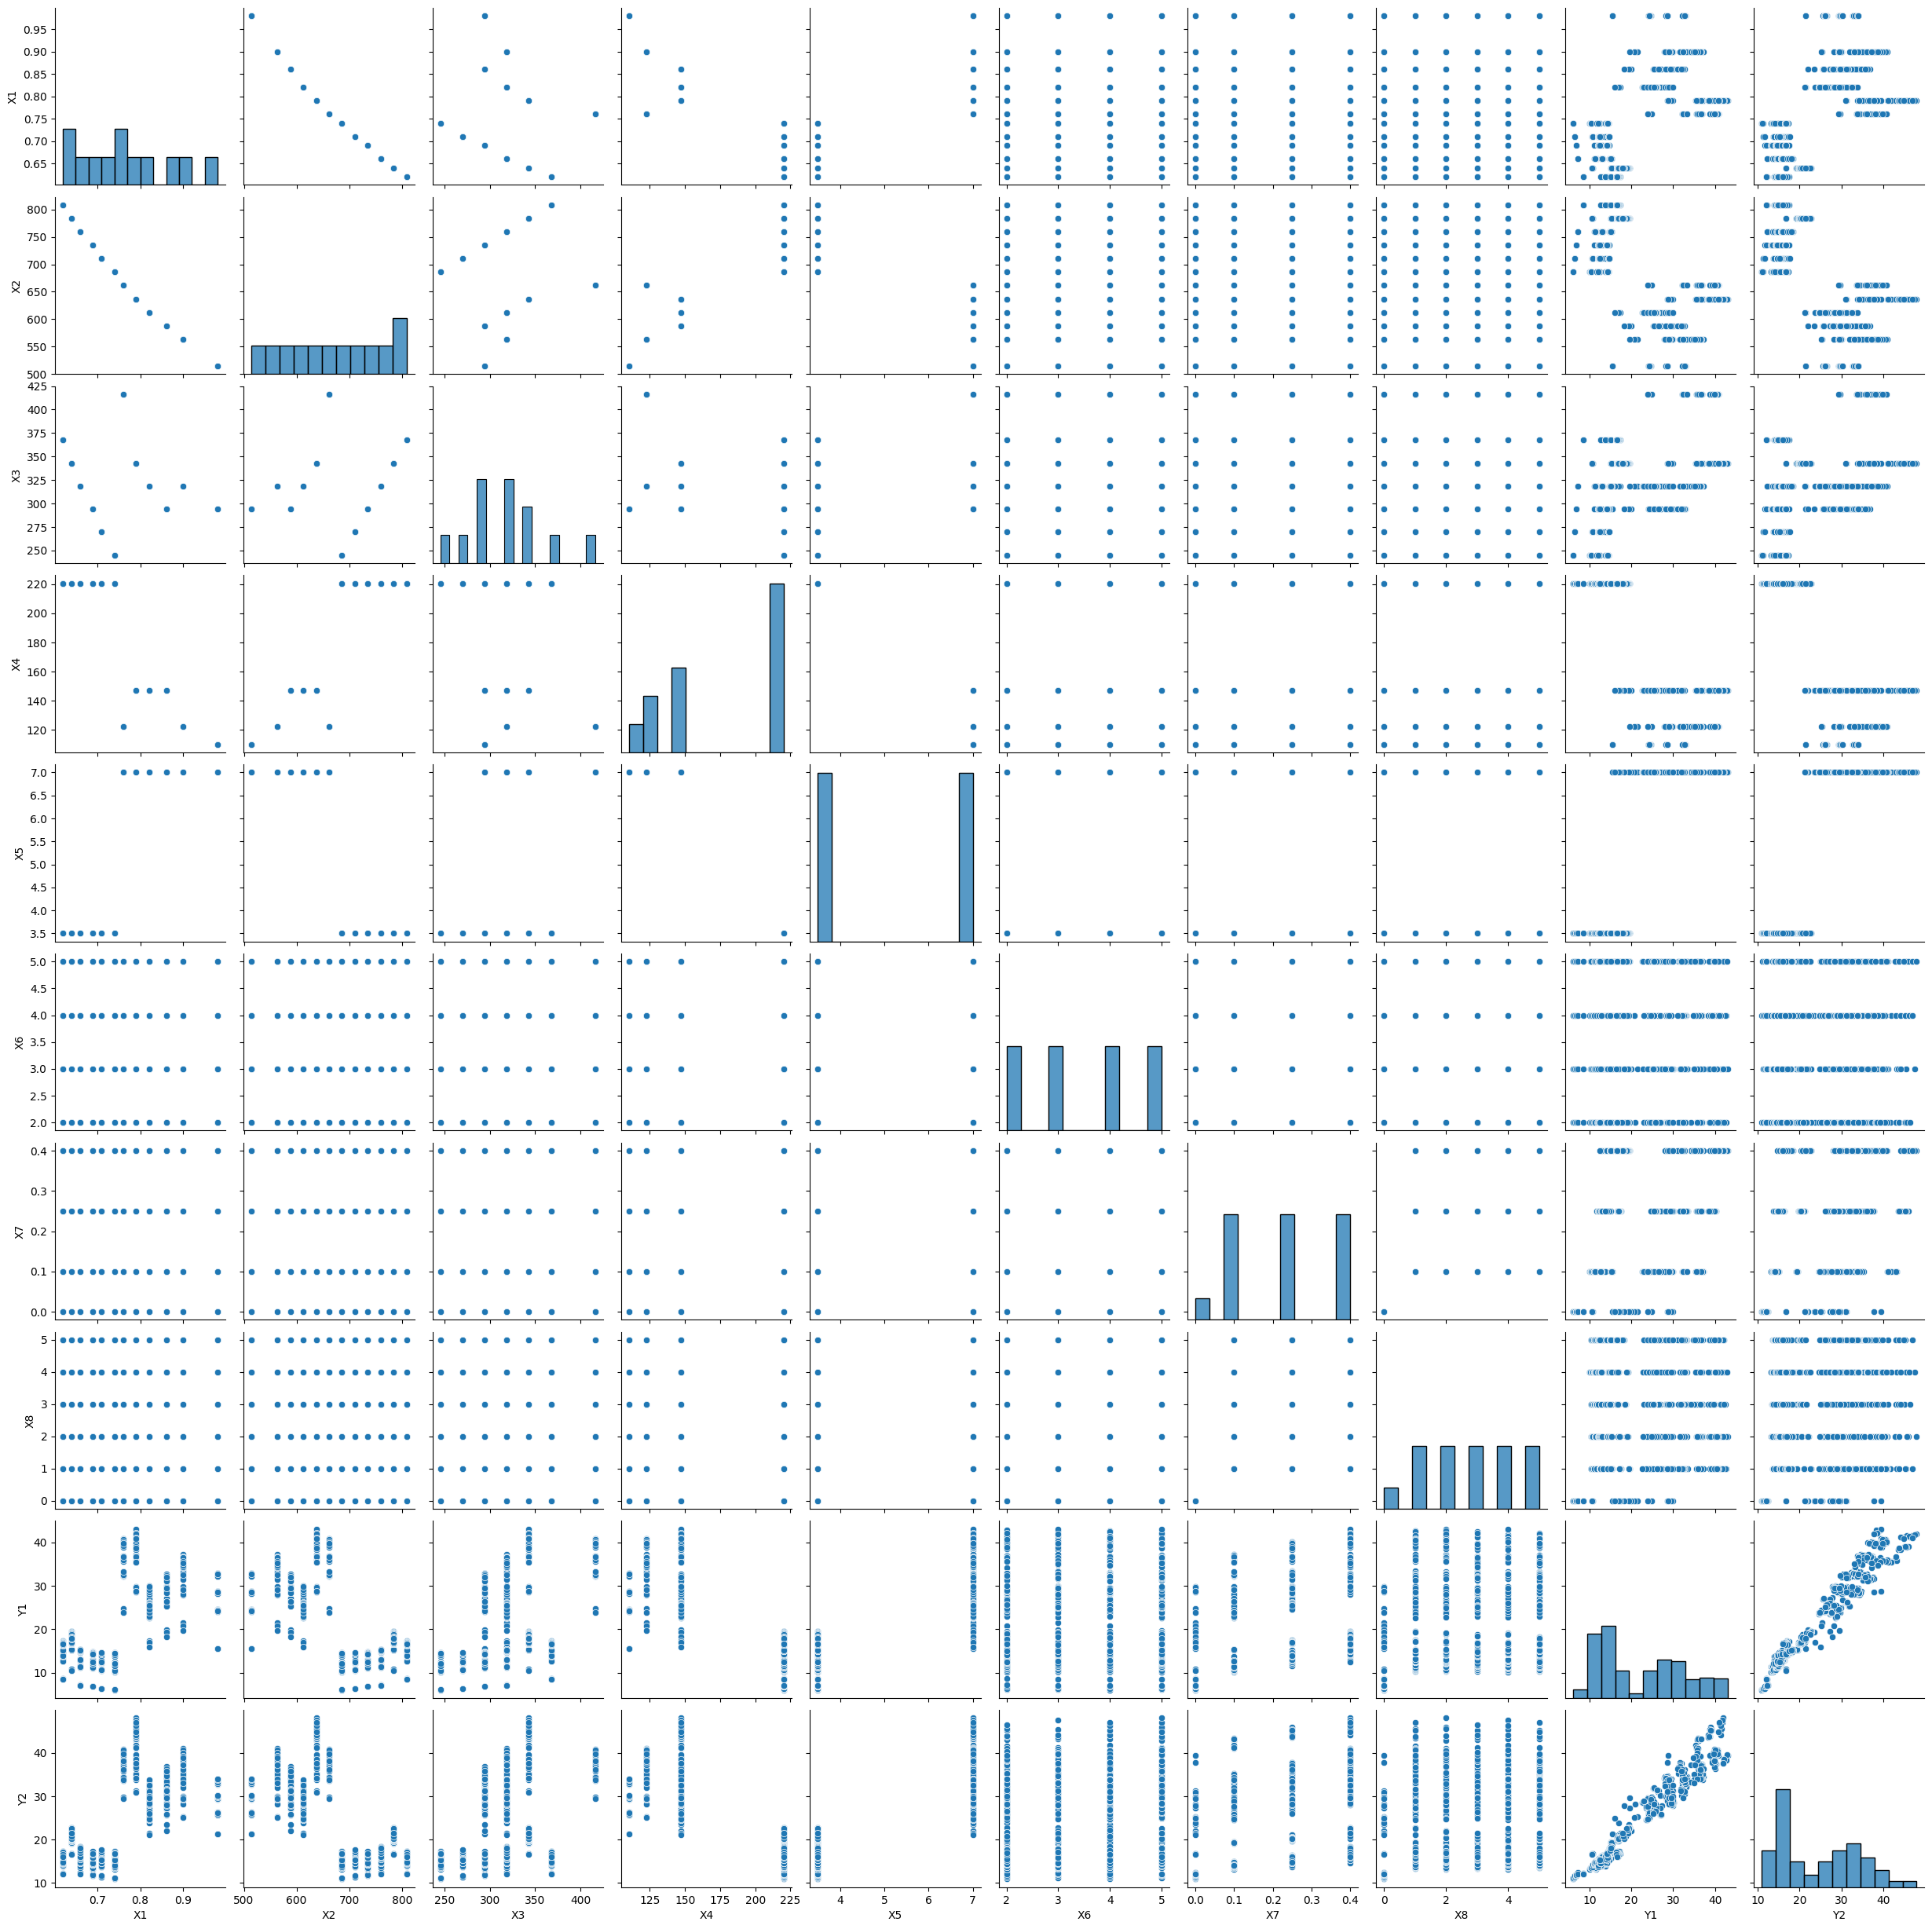

In [14]:
sns.pairplot(df)
plt.show()

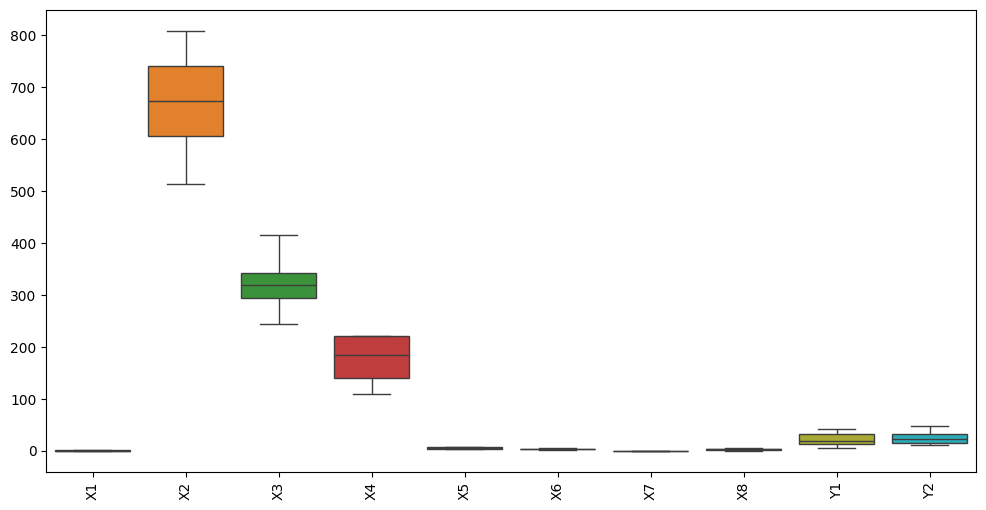

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

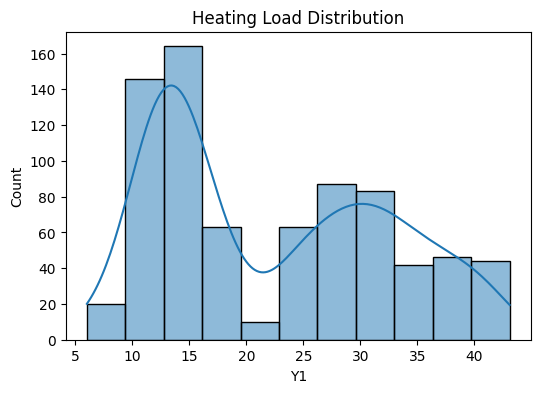

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df["Y1"], kde=True)
plt.title("Heating Load Distribution")
plt.show()

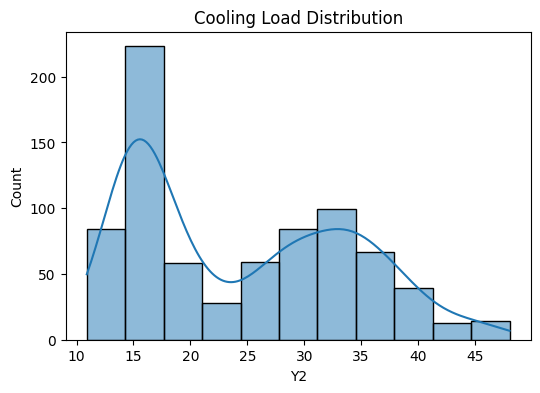

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df["Y2"], kde=True)
plt.title("Cooling Load Distribution")
plt.show()

In [30]:
X = df[['X1','X2','X3','X4','X5','X6','X7','X8']]
y = df['Y1']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [33]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))

R2 Score: 0.912184095154691
MSE: 9.153187855202752


In [34]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_dt))

R2 Score: 0.9963040205845394


In [35]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_rf))

R2 Score: 0.9977199881439125


In [36]:
models = ['Linear Regression','Decision Tree','Random Forest']
scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

for m,s in zip(models,scores):
    print(m,":",s)

Linear Regression : 0.912184095154691
Decision Tree : 0.9963040205845394
Random Forest : 0.9977199881439125


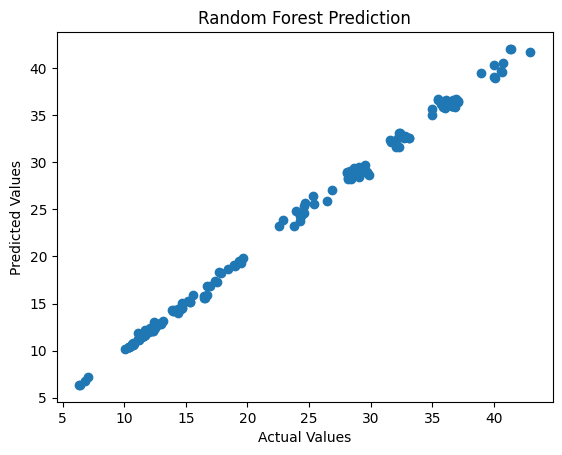

In [37]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Prediction")
plt.show()

In [38]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [39]:
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

R2 Score: 0.912184095154691
MSE: 9.153187855202752
RMSE: 3.0254235827736173
MAE: 2.1820470221279193


In [40]:
print("R2 Score:", r2_score(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))

R2 Score: 0.9963040205845394
MSE: 0.3852376623376626


In [41]:
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

R2 Score: 0.9977199881439125
MSE: 0.23764916922077722


In [42]:
df['Y1_class'] = (df['Y1'] > df['Y1'].median()).astype(int)

In [43]:
df[['Y1','Y1_class']].head()

,Y1,Y1_class
0,15.55,0
1,15.55,0
2,15.55,0
3,15.55,0
4,20.84,1


In [44]:
X = df[['X1','X2','X3','X4','X5','X6','X7','X8']]
y = df['Y1_class']

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9805194805194806
Precision: 0.9878048780487805
Recall: 0.9759036144578314
F1 Score: 0.9818181818181818


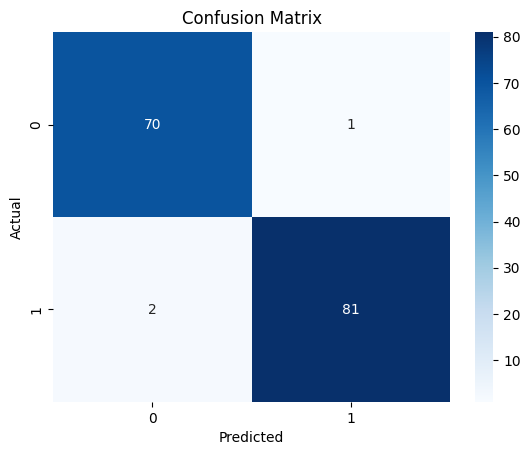

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

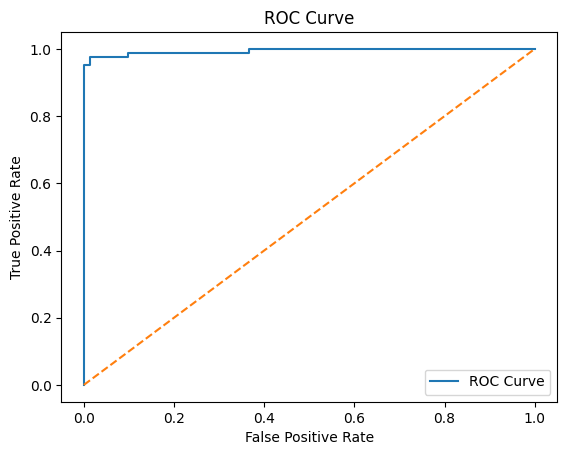

AUC Score: 0.9940607500424232


In [49]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

In [50]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.987012987012987


In [51]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.9805194805194806


In [52]:
print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.9805194805194806
Decision Tree: 0.987012987012987
Random Forest: 0.9805194805194806


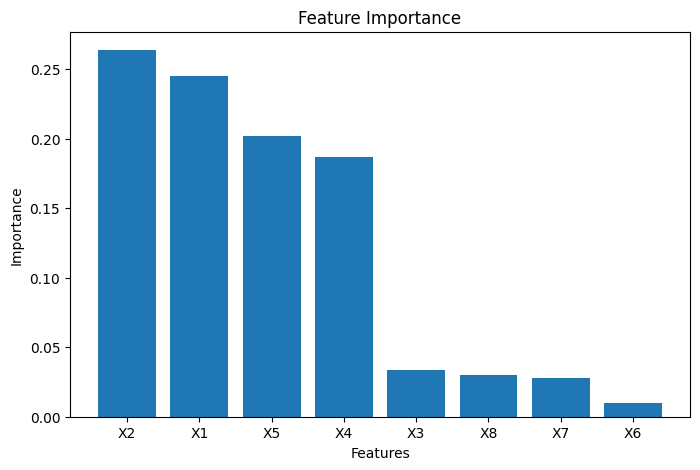

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

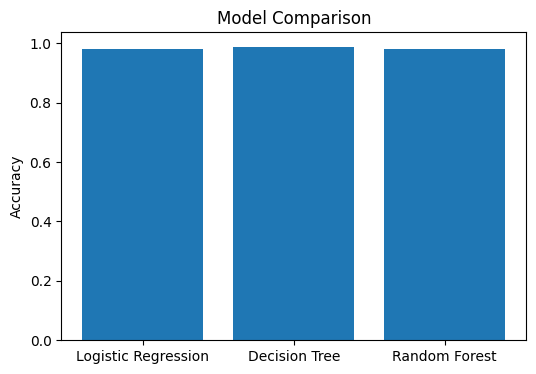

In [54]:
import matplotlib.pyplot as plt

models = ['Logistic Regression','Decision Tree','Random Forest']

scores = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [56]:
sample = pd.DataFrame(
    [[0.75, 563.5, 318.5, 122.5, 7, 2, 0.4, 2]],
    columns=['X1','X2','X3','X4','X5','X6','X7','X8']
)

prediction = rf.predict(sample)

print("Predicted Class:", prediction)

Predicted Class: [1]


In [4]:
import pandas as pd

df = pd.read_csv("Energy1.csv")
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [5]:
X = df.drop('Y1', axis=1)
y = df['Y1']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

R2 Score: 0.962683705540927
Mean Squared Error: 3.8895352025995003


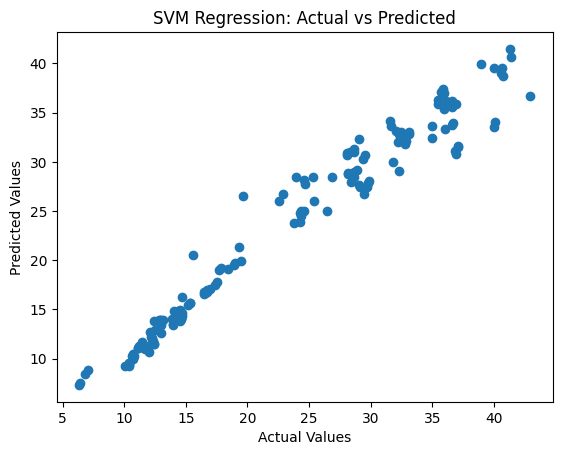

In [8]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Create SVR model
svm_model = SVR(kernel='linear')

# Train model
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred_svm))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_svm))

# Scatter plot (Actual vs Predicted)
plt.scatter(y_test, y_pred_svm)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVM Regression: Actual vs Predicted")
plt.show()

R2 Score: 0.9751841286698537
Mean Squared Error: 2.5865967272727293


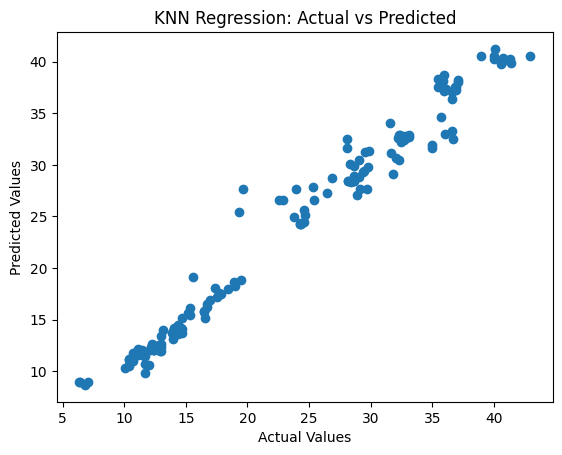

In [9]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_knn))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_knn))

plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("KNN Regression: Actual vs Predicted")
plt.show()